<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex06/Bert_2_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 필수 패키지 설치 명령어 (Jupyter Notebook 등에서는 앞에 !를 붙여 실행)
!pip install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import pandas as pd

# 파일 경로 (Colab 환경에 맞게)
file_path = '/content/TextDown_20260216_pm061913_2500.xlsx'

# CSV가 아닌 엑셀 파일이므로 pd.read_excel() 사용
df = pd.read_excel(file_path)

# 미국 학회용이므로 영어 원문이 있는 '요약' 컬럼 사용
text_col = '요약'
date_col = '출원일'

# 결측치 제거
df = df.dropna(subset=[text_col, date_col]).reset_index(drop=True)


# 시간 데이터 처리 (출원일에서 연도(Year) 추출)
df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df['year'] = df['datetime'].dt.year

docs = df[text_col].tolist()
timestamps = df['year'].tolist()

# 2. BERTopic 모델 구성 요소 설정
# 2-1. 임베딩 모델: 영어 텍스트에 가장 널리 쓰이고 가볍고 성능이 좋은 모델
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2-2. 차원 축소: UMAP
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 2-3. 군집화: HDBSCAN
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 2-4. 토픽 표현: 영어 불용어(stop words) 제거
vectorizer_model = CountVectorizer(stop_words='english')

# 3. BERTopic 모델 초기화 및 학습
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 전체 문서에 대해 토픽 피팅
topics, probs = topic_model.fit_transform(docs)

# 4. 시간에 따른 토픽 모델링 (Dynamic Topic Modeling)
# global_tuning=True를 통해 전체 토픽 표현과 시간별 토픽 표현의 일관성 유지
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)

# 5. 시각화 및 결과 확인
# 시간에 따른 토픽 트렌드 시각화 (상위 10개 토픽)
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig.show() # jupyter notebook 등에서 바로 확인 가능
# fig.write_html("dtm_plot.html") # HTML 파일로 저장하고 싶을 때 사용

# 각 시간대별 토픽 데이터프레임 저장 (분석용)
topics_over_time.to_csv("topics_over_time_result.csv", index=False, encoding='utf-8-sig')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-02-25 09:21:53,087 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

2026-02-25 09:21:57,820 - BERTopic - Embedding - Completed ✓
2026-02-25 09:21:57,821 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-25 09:22:17,158 - BERTopic - Dimensionality - Completed ✓
2026-02-25 09:22:17,159 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 09:22:17,306 - BERTopic - Cluster - Completed ✓
2026-02-25 09:22:17,311 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 09:22:17,607 - BERTopic - Representation - Completed ✓
14it [00:01, 12.90it/s]


In [ ]:
# 전체 문서에서 어떤 토픽들이 도출되었는지 표 형태로 확인
topic_info = topic_model.get_topic_info()
display(topic_info) # 상위 15개 토픽 출력

,Topic,Count,Name,Representation,Representative_Docs
0,-1,856,-1_cells_stem_methods_cell,"[cells, stem, methods, cell, provided, method,...",[The invention relates to a method for obtaini...
1,0,237,0_meat_culture_cultured_food,"[meat, culture, cultured, food, product, based...",[The present invention relates to the field of...
2,1,116,1_neural_neurons_cells_brain,"[neural, neurons, cells, brain, spinal, neuron...",[The method relates to an in vitro method of p...
3,2,109,2_somatic_reprogramming_pluripotent_cells,"[somatic, reprogramming, pluripotent, cells, i...",[The disclosure relates to a method of reprogr...
4,3,87,3_satellite_network_ue_information,"[satellite, network, ue, information, communic...",[A system and method for delivering and receiv...
5,4,84,4_adipocytes_brown_fat_adipose,"[adipocytes, brown, fat, adipose, adipocyte, c...",[The present invention concerns a method of pr...
6,5,79,5_mesenchymal_mscs_stem_solution,"[mesenchymal, mscs, stem, solution, msc, metho...",[A method for culturing mesenchymal stem cells...
7,6,68,6_organoids_intestinal_organoid_epithelial,"[organoids, intestinal, organoid, epithelial, ...",[A method is provided for producing renal orga...
8,7,51,7_cardiac_cardiomyocytes_ventricular_heart,"[cardiac, cardiomyocytes, ventricular, heart, ...",[A method for producing a cell population cont...
9,8,49,8_retinal_rpe_pigment_epithelial,"[retinal, rpe, pigment, epithelial, photorecep...",[This invention relates to methods for improve...


In [ ]:
# 전체 문서에서 어떤 토픽들이 도출되었는지 표 형태로 확인
topic_info = topic_model.get_topic_info()
display(topic_info.head(15)) # 상위 15개 토픽 출력

,Topic,Count,Name,Representation,Representative_Docs
0,-1,856,-1_cells_stem_methods_cell,"[cells, stem, methods, cell, provided, method,...",[The invention relates to a method for obtaini...
1,0,237,0_meat_culture_cultured_food,"[meat, culture, cultured, food, product, based...",[The present invention relates to the field of...
2,1,116,1_neural_neurons_cells_brain,"[neural, neurons, cells, brain, spinal, neuron...",[The method relates to an in vitro method of p...
3,2,109,2_somatic_reprogramming_pluripotent_cells,"[somatic, reprogramming, pluripotent, cells, i...",[The disclosure relates to a method of reprogr...
4,3,87,3_satellite_network_ue_information,"[satellite, network, ue, information, communic...",[A system and method for delivering and receiv...
5,4,84,4_adipocytes_brown_fat_adipose,"[adipocytes, brown, fat, adipose, adipocyte, c...",[The present invention concerns a method of pr...
6,5,79,5_mesenchymal_mscs_stem_solution,"[mesenchymal, mscs, stem, solution, msc, metho...",[A method for culturing mesenchymal stem cells...
7,6,68,6_organoids_intestinal_organoid_epithelial,"[organoids, intestinal, organoid, epithelial, ...",[A method is provided for producing renal orga...
8,7,51,7_cardiac_cardiomyocytes_ventricular_heart,"[cardiac, cardiomyocytes, ventricular, heart, ...",[A method for producing a cell population cont...
9,8,49,8_retinal_rpe_pigment_epithelial,"[retinal, rpe, pigment, epithelial, photorecep...",[This invention relates to methods for improve...


In [ ]:
# 시간에 따른 토픽 트렌드 시각화 (상위 10개 토픽)
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig.show()

In [ ]:
import pandas as pd

# 1. 문서 정보 및 연도 데이터 준비
document_info = topic_model.get_document_info(docs)
document_info['Year'] = timestamps

# 2. 분석에 방해되는 -1번 토픽(노이즈/Outlier) 데이터 제외
df_filtered = document_info[document_info['Topic'] != -1]

# 3. 연도별, 토픽별 빈도수 계산
topic_freq_by_year = df_filtered.groupby(['Year', 'Topic', 'Name']).size().reset_index(name='Count')

# 4. ★ 핵심: 연도별로 빈도수(Count)가 가장 높은 1위 토픽만 추출 ★
# 각 연도(Year) 그룹에서 Count가 가장 큰 행의 인덱스(idxmax)를 찾아 필터링합니다.
top1_topic_per_year = topic_freq_by_year.loc[topic_freq_by_year.groupby('Year')['Count'].idxmax()]

# 5. 연도순으로 정렬
top1_topic_per_year = top1_topic_per_year.sort_values(by='Year').reset_index(drop=True)

# 6. 화면에 결과 출력
print("=== 연도별 주도 기술 트렌드 (1위 토픽) ===")
display(top1_topic_per_year)

# 7. 논문 작업용 엑셀(CSV) 파일로 저장
top1_topic_per_year.to_csv("Top1_Topic_per_Year.csv", index=False, encoding='utf-8-sig')
print("\n'Top1_Topic_per_Year.csv' 파일이 성공적으로 저장되었습니다!")

=== 연도별 주도 기술 트렌드 (1위 토픽) ===


,Year,Topic,Name,Count
0,2010,11,11_human_non_animal_animals,1
1,2014,1,1_neural_neurons_cells_brain,1
2,2015,14,14_memory_cd4_cells_cd8,2
3,2016,2,2_somatic_reprogramming_pluripotent_cells,6
4,2017,1,1_neural_neurons_cells_brain,11
5,2018,1,1_neural_neurons_cells_brain,7
6,2019,1,1_neural_neurons_cells_brain,13
7,2020,0,0_meat_culture_cultured_food,15
8,2021,0,0_meat_culture_cultured_food,47
9,2022,0,0_meat_culture_cultured_food,66



'Top1_Topic_per_Year.csv' 파일이 성공적으로 저장되었습니다!


In [ ]:
# 1. 문서들의 임베딩(벡터) 값 추출
# (시각화를 위해 문서를 2차원 좌표로 변환할 때 필요합니다)
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# 2. UMAP을 이용한 2D 문서 군집 시각화
# 각 점에 마우스를 올리면 해당 문서의 실제 텍스트 내용과 토픽 번호를 볼 수 있습니다.
fig_docs = topic_model.visualize_documents(docs, embeddings=embeddings)

# 3. 그래프 출력 (Jupyter Notebook / Colab 화면에 띄우기)
fig_docs.show()

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
fig_docs.show()

In [ ]:
import umap
import pandas as pd
import plotly.express as px

# 1. 문서들의 임베딩(벡터) 추출 (이전에 실행했다면 생략 가능하지만 안전하게 다시 추출)
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# 2. UMAP을 사용하여 데이터를 3차원(3D)으로 축소 (n_components=3)
umap_3d = umap.UMAP(n_neighbors=15, n_components=3, min_dist=0.0, metric='cosine', random_state=42)
embeddings_3d = umap_3d.fit_transform(embeddings)

# 3. 3D 시각화를 위한 데이터프레임 만들기
# 각 문서의 3D 좌표(x, y, z), 토픽 번호, 토픽 이름, 문서 내용(요약)을 하나로 묶습니다.
df_3d = pd.DataFrame(embeddings_3d, columns=['x', 'y', 'z'])
df_3d['Topic'] = document_info['Topic']
df_3d['Topic_Name'] = document_info['Name']

# Hover(마우스 오버) 시 보여줄 텍스트 (너무 길면 잘리므로 앞 100글자만 자름)
df_3d['Text'] = [doc[:100] + "..." for doc in docs]

# 분석에 방해되는 노이즈(-1 토픽)는 회색으로 처리하거나 아예 제외할 수 있습니다.
# 여기서는 시각적 깔끔함을 위해 -1번 토픽(노이즈)을 제외하고 그립니다.
df_3d_filtered = df_3d[df_3d['Topic'] != -1]

# 토픽 번호를 문자열로 변환 (Plotly에서 이산형 컬러맵을 사용하기 위해)
df_3d_filtered['Topic'] = df_3d_filtered['Topic'].astype(str)

# 4. Plotly를 이용한 3D 산점도 그리기
fig_3d = px.scatter_3d(
    df_3d_filtered,
    x='x', y='y', z='z',
    color='Topic_Name', # 토픽 이름에 따라 색상 다르게 지정
    hover_name='Topic_Name',
    hover_data={'x': False, 'y': False, 'z': False, 'Text': True}, # Hover 시 텍스트 보여주기
    title="3D UMAP Document Clusters by Topic",
    opacity=0.7, # 점들이 겹칠 때를 대비해 약간 투명하게 설정
    size_max=5
)

# 점 크기 미세 조정
fig_3d.update_traces(marker=dict(size=3))

# 배경 및 레이아웃 설정 (깔끔하게)
fig_3d.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(itemsizing='constant')
)

# 5. 화면에 출력
fig_3d.show()

# 6. HTML 파일로 저장 (팀원 공유 및 학회 발표 자료용)
fig_3d.write_html("3D_UMAP_Clusters.html")
print("\n'3D_UMAP_Clusters.html' 파일이 저장되었습니다. 더블클릭해서 웹 브라우저 전체화면으로 감상해 보세요!")

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


'3D_UMAP_Clusters.html' 파일이 저장되었습니다. 더블클릭해서 웹 브라우저 전체화면으로 감상해 보세요!


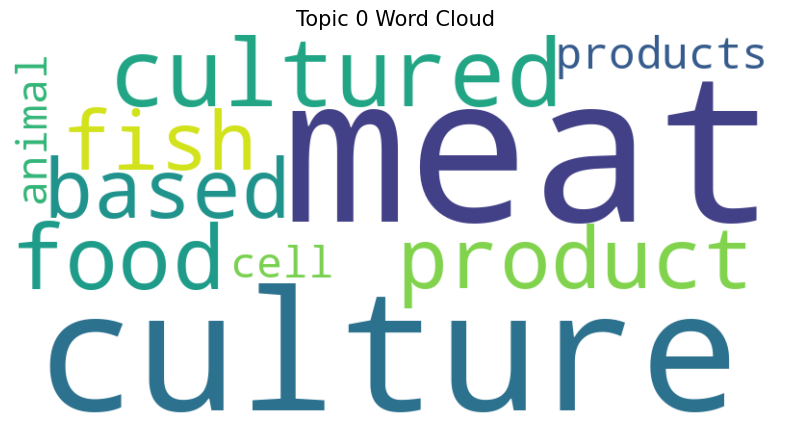

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 특정 토픽(예: 0번 토픽)의 단어와 가중치를 딕셔너리 형태로 가져오기
topic_id = 0
topic_words = dict(topic_model.get_topic(topic_id))

# 워드클라우드 객체 생성 (가중치 기반)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_words)

# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Topic {topic_id} Word Cloud", fontsize=15)
plt.show()

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. 정제된 데이터 불러오기 (제가 필터링해 드린 파일 경로로 지정해주세요)
file_path = '/content/filtered_clean_data.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

text_col = '요약'
date_col = '출원일'

# 결측치 제거
df = df.dropna(subset=[text_col, date_col]).reset_index(drop=True)

# 시간 데이터 처리 (출원일에서 연도 추출)
df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df['year'] = df['datetime'].dt.year

docs = df[text_col].tolist()
timestamps = df['year'].tolist()

# 2. BERTopic 모델 구성 (이전과 동일한 커스텀 세팅)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# ★ 데이터 개수가 1952개로 줄었기 때문에 min_cluster_size를 10 정도로 낮추는 것도 추천합니다.
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 3. 모델 피팅
topics, probs = topic_model.fit_transform(docs)

# 4. 시각화 (바 차트 및 토픽 맵) - 결과 확인용
fig_bar = topic_model.visualize_barchart(top_n_topics=10)
fig_bar.show()

fig_map = topic_model.visualize_topics()
fig_map.show()

# 5. DTM (시간에 따른 토픽)
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# 결과 확인
print(topic_model.get_topic_info().head(10))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-25 10:05:04,189 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-02-25 10:05:08,349 - BERTopic - Embedding - Completed ✓
2026-02-25 10:05:08,352 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-25 10:05:17,862 - BERTopic - Dimensionality - Completed ✓
2026-02-25 10:05:17,863 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 10:05:17,933 - BERTopic - Cluster - Completed ✓
2026-02-25 10:05:17,936 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 10:05:18,062 - BERTopic - Representation - Completed ✓


13it [00:00, 21.80it/s]


   Topic  Count                                        Name  \
0     -1    570           -1_stem_cells_pluripotent_methods   
1      0    199                0_meat_cultured_culture_cell   
2      1    145               1_neural_neurons_cells_spinal   
3      2    107                  2_human_non_animals_animal   
4      3     87          3_satellite_network_ue_information   
5      4     73           4_mesenchymal_mscs_stem_umbilical   
6      5     60              5_adipocytes_fat_brown_extract   
7      6     52       6_somatic_reprogramming_induced_cells   
8      7     50  7_cardiac_cardiomyocytes_ventricular_heart   
9      8     49  8_intestinal_organoid_organoids_epithelial   

                                      Representation  \
0  [stem, cells, pluripotent, methods, cell, comp...   
1  [meat, cultured, culture, cell, product, food,...   
2  [neural, neurons, cells, spinal, brain, stem, ...   
3  [human, non, animals, animal, locus, humanized...   
4  [satellite, network, ue

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. 정제된 데이터 불러오기 (경로를 맞게 수정해주세요)
file_path = '/content/filtered_clean_data.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 필요한 컬럼 추출 및 전처리
text_col = '요약'
date_col = '출원일'

df = df.dropna(subset=[text_col, date_col]).reset_index(drop=True)

# 연도(Year) 추출
df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df['year'] = df['datetime'].dt.year

docs = df[text_col].tolist()
timestamps = df['year'].tolist()

# 2. BERTopic 모델 설정
# (데이터 모수가 줄었으므로 min_cluster_size를 10으로 낮춰서 작은 토픽도 잘 잡도록 세팅)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 3. 모델 학습
topics, probs = topic_model.fit_transform(docs)

# ---------------------------------------------------------
# [핵심 1] 시간에 따른 토픽 변화(DTM) 분석 및 추세 그래프
# ---------------------------------------------------------
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)

# 추세 변화 그래프 시각화 (가장 비중이 큰 상위 10개 토픽 기준)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# ---------------------------------------------------------
# [핵심 2] 연도별 가장 많이 등장한(출원된) 토픽 순위 뽑기
# ---------------------------------------------------------
# Topic -1 (노이즈)는 순위 분석에서 제외
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]

# 연도(Timestamp)별로 그룹화하여 빈도수(Frequency) 기준으로 내림차순 정렬
# 각 연도별로 가장 빈도수가 높은 상위 3개 토픽만 추출
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(1)
)

# 결과 출력을 위해 보기 좋게 컬럼 정리
result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '문서수(빈도)', '핵심키워드']

print("=== 연도별 상위 토픽 TOP 3 ===")
display(result_df) # Colab에서 표 형태로 예쁘게 출력

# 보고용 엑셀 파일로 저장
result_df.to_excel("연도별_상위토픽_분석결과.xlsx", index=False)
topics_over_time.to_excel("전체_시간에따른_토픽변화.xlsx", index=False)
print("✅ 분석 결과가 엑셀 파일로 저장되었습니다!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-25 10:09:40,711 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

2026-02-25 10:09:46,230 - BERTopic - Embedding - Completed ✓
2026-02-25 10:09:46,233 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-25 10:10:00,500 - BERTopic - Dimensionality - Completed ✓
2026-02-25 10:10:00,501 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-25 10:10:00,568 - BERTopic - Cluster - Completed ✓
2026-02-25 10:10:00,572 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-25 10:10:00,716 - BERTopic - Representation - Completed ✓
13it [00:00, 17.80it/s]


=== 연도별 상위 토픽 TOP 3 ===


,연도,토픽번호,문서수(빈도),핵심키워드
0,2011,23,1,"subunits, bioengineered, complex, undifferenti..."
2,2014,0,1,"mge, epilepsy, eminence, ganglionic, fgf8"
5,2015,0,1,"hbecs, zo, bbb, brain, apcdd1"
12,2016,7,3,"hbf, hemoglobinopathies, editing, crispr, appl..."
23,2017,0,10,"neural, neuronal, midbrain, signaling, deriving"
46,2018,0,7,"zinc, neural, seq, containing, neurons"
74,2019,0,13,"neural, spinal, neurons, brain, cord"
107,2020,1,12,"satellite, information, network, fixed, cellular"
147,2021,0,22,"neural, brain, neurons, nerve, cells"
193,2022,3,20,"adipocytes, extract, composition, adipocyte, s..."


✅ 분석 결과가 엑셀 파일로 저장되었습니다!


In [ ]:
fig_dtm.show()

## Combined_clean_data

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. 정제된 데이터 불러오기 (수정 완료: read_csv 사용)
file_path = '/content/combined_clean_data.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

text_col = '요약'
date_col = '출원일'

# 결측치 제거
df = df.dropna(subset=[text_col, date_col]).reset_index(drop=True)

# 시간 데이터 처리 (출원일에서 연도 추출)
df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df['year'] = df['datetime'].dt.year

docs = df[text_col].tolist()
timestamps = df['year'].tolist()

# 2. BERTopic 모델 구성
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# ★ 데이터가 2,630개로 풍부해졌으므로 min_cluster_size=15 유지!
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 3. 모델 피팅
topics, probs = topic_model.fit_transform(docs)

# 4. 시각화 (바 차트 및 토픽 맵)
print("=== 토픽 바 차트 및 거리 지도 시각화 ===")
fig_bar = topic_model.visualize_barchart(top_n_topics=10)
fig_bar.show()

fig_map = topic_model.visualize_topics()
fig_map.show()

# 5. DTM (시간에 따른 토픽) 및 결과 저장
print("=== 시간에 따른 토픽 변화(DTM) 시각화 ===")
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# [추가] 연도별 상위 3개 토픽 추출 및 엑셀 저장
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(3)
)

result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '문서수(빈도)', '핵심키워드']

result_df.to_excel("연도별_상위토픽_분석결과.xlsx", index=False)
topics_over_time.to_excel("전체_시간에따른_토픽변화.xlsx", index=False)

print("\n=== 기본 토픽 정보 (Top 10) ===")
print(topic_model.get_topic_info().head(10))
print("\n✅ 모든 분석이 완료되었고, 연도별 분석 결과가 엑셀로 저장되었습니다!")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-02-27 07:32:14,703 - BERTopic - Embedding - Completed ✓
2026-02-27 07:32:14,705 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-27 07:32:34,045 - BERTopic - Dimensionality - Completed ✓
2026-02-27 07:32:34,046 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-27 07:32:34,145 - BERTopic - Cluster - Completed ✓
2026-02-27 07:32:34,150 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-27 07:32:34,312 - BERTopic - Representation - Completed ✓


=== 토픽 바 차트 및 거리 지도 시각화 ===


=== 시간에 따른 토픽 변화(DTM) 시각화 ===


43it [00:01, 27.59it/s]



=== 기본 토픽 정보 (Top 10) ===
   Topic  Count                                         Name  \
0     -1    848                   -1_stem_cells_cell_methods   
1      0    144                0_neural_neurons_cells_spinal   
2      1    107                    1_human_non_animals_locus   
3      2    100            2_muscle_adipocytes_adipose_brown   
4      3     90        3_hematopoietic_cells_hscs_progenitor   
5      4     87         4_satellite_network_ue_communication   
6      5     73                    5_media_serum_medium_free   
7      6     68                  6_mesenchymal_mscs_stem_msc   
8      7     67           7_scaffold_scaffolds_meat_cultured   
9      8     67  8_somatic_reprogramming_pluripotent_induced   

                                      Representation  \
0  [stem, cells, cell, methods, method, provided,...   
1  [neural, neurons, cells, spinal, brain, opcs, ...   
2  [human, non, animals, locus, humanized, animal...   
3  [muscle, adipocytes, adipose, brown, comp

In [ ]:
fig_dtm.show()

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. 정제된 데이터 불러오기 (경로를 맞게 수정해주세요)
file_path = '/content/combined_clean_data.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 필요한 컬럼 추출 및 전처리
text_col = '요약'
date_col = '출원일'

df = df.dropna(subset=[text_col, date_col]).reset_index(drop=True)

# 연도(Year) 추출
df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)
df['year'] = df['datetime'].dt.year

docs = df[text_col].tolist()
timestamps = df['year'].tolist()

# 2. BERTopic 모델 설정
# (데이터 모수가 줄었으므로 min_cluster_size를 10으로 낮춰서 작은 토픽도 잘 잡도록 세팅)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 3. 모델 학습
topics, probs = topic_model.fit_transform(docs)

# ---------------------------------------------------------
# [핵심 1] 시간에 따른 토픽 변화(DTM) 분석 및 추세 그래프
# ---------------------------------------------------------
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)

# 추세 변화 그래프 시각화 (가장 비중이 큰 상위 10개 토픽 기준)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# ---------------------------------------------------------
# [핵심 2] 연도별 가장 많이 등장한(출원된) 토픽 순위 뽑기
# ---------------------------------------------------------
# Topic -1 (노이즈)는 순위 분석에서 제외
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]

# 연도(Timestamp)별로 그룹화하여 빈도수(Frequency) 기준으로 내림차순 정렬
# 각 연도별로 가장 빈도수가 높은 상위 3개 토픽만 추출
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(1)
)

# 결과 출력을 위해 보기 좋게 컬럼 정리
result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '문서수(빈도)', '핵심키워드']

print("=== 연도별 상위 토픽 TOP 3 ===")
display(result_df) # Colab에서 표 형태로 예쁘게 출력

# 보고용 엑셀 파일로 저장
result_df.to_excel("연도별_상위토픽_분석결과.xlsx", index=False)
topics_over_time.to_excel("전체_시간에따른_토픽변화.xlsx", index=False)
print("✅ 분석 결과가 엑셀 파일로 저장되었습니다!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-27 07:32:41,913 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/83 [00:00<?, ?it/s]

2026-02-27 07:32:46,067 - BERTopic - Embedding - Completed ✓
2026-02-27 07:32:46,070 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-27 07:32:59,740 - BERTopic - Dimensionality - Completed ✓
2026-02-27 07:32:59,741 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-27 07:32:59,825 - BERTopic - Cluster - Completed ✓
2026-02-27 07:32:59,829 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-27 07:33:00,009 - BERTopic - Representation - Completed ✓
43it [00:01, 37.27it/s]


=== 연도별 상위 토픽 TOP 3 ===


,연도,토픽번호,문서수(빈도),핵심키워드
0,1979,23,1,"microfibrillar, 10μ, heat, resistance, texture"
1,1980,14,1,"pentosaceus, meat, pediococcus, temperatures, 465"
2,1981,16,1,"stage, effluent, finfish, shrimp, plankton"
3,1982,21,1,"lactobacillus, 036, nrrl, sp, 15"
4,1984,17,1,"trays, water, shellfish, apparatus, holding"
5,1985,27,1,"cavities, diffusers, lumps, air, holes"
6,1987,21,1,"plasmid, phage, insensitivity, streptococcus, ..."
7,1988,31,1,"neutrons, neutrotrophic, acetylcholine, parasy..."
10,1992,21,1,"reuteri, lactobacillus, whey, organisms, feeding"
13,1993,17,1,"shellfish, securement, rope, stocking, seeding"


✅ 분석 결과가 엑셀 파일로 저장되었습니다!


## 논문데이터

In [ ]:
import pandas as pd
import glob
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ---------------------------------------------------------
# 1. 논문 데이터 11개 자동 검색 및 병합
# ---------------------------------------------------------
# 'culturedmeat_study'로 시작하는 모든 파일 찾기 (확장자 무관)
file_pattern = '/content/culturedmeat_study*'
file_list = glob.glob(file_pattern)

print(f"총 {len(file_list)}개의 파일을 찾았습니다.\n")

df_list = []
for file in file_list:
    try:
        # 파일이 CSV 형태인 경우
        if file.endswith('.csv'):
            temp_df = pd.read_csv(file, encoding='utf-8')
        # 파일이 엑셀 형태인 경우
        elif file.endswith(('.xls', '.xlsx')):
            temp_df = pd.read_excel(file)
        else:
            continue # 데이터 파일이 아니면 건너뜀

        df_list.append(temp_df)
        print(f"✅ 성공: {file.split('/')[-1]}")

    except Exception as e:
        print(f"❌ 오류 ({file.split('/')[-1]}): {e}")

# 리스트에 담긴 모든 데이터프레임을 하나로 병합
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)

    # 중복 논문 제거 (제목 기준)
    if 'Article Title' in combined_df.columns:
        combined_df = combined_df.drop_duplicates(subset=['Article Title']).reset_index(drop=True)

    print(f"\n🎉 병합 완료! 중복 제거 후 총 논문 개수: {len(combined_df)}건")
else:
    print("\n데이터를 하나도 불러오지 못했습니다. 파일이 Colab에 잘 업로드되었는지 확인해주세요.")

# ---------------------------------------------------------
# 2. 텍스트 및 시간 데이터 전처리
# ---------------------------------------------------------
# 논문은 'Abstract'(초록)과 'Publication Year'(출판 연도)를 사용합니다.
text_col = 'Abstract'
date_col = 'Publication Year'

# 결측치 제거
combined_df = combined_df.dropna(subset=[text_col, date_col]).reset_index(drop=True)

# 출판 연도를 정수형(int)으로 확실하게 변환
combined_df['year'] = combined_df[date_col].astype(int)

docs = combined_df[text_col].tolist()
timestamps = combined_df['year'].tolist()

# ---------------------------------------------------------
# 3. BERTopic 모델 구성 및 학습 (아래부터는 기존과 동일)
# ---------------------------------------------------------
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=20, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 논문용 불용어 추가
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words())
custom_stop_words.extend(['paper', 'study', 'results', 'showed', 'used', 'using', 'research', 'article'])
vectorizer_model = CountVectorizer(stop_words=custom_stop_words)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 모델 학습
print("\n🚀 BERTopic 모델 학습을 시작합니다. 데이터가 많아 시간이 조금 걸릴 수 있습니다...")
topics, probs = topic_model.fit_transform(docs)

# ---------------------------------------------------------
# 4. 시간에 따른 토픽 변화(DTM) 시각화 및 저장
# ---------------------------------------------------------
print("\n=== 시간에 따른 토픽 변화(DTM) 시각화 ===")
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# 연도별 상위 3개 토픽 추출
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(3)
)

result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '논문수(빈도)', '핵심키워드']

result_df.to_excel("논문_연도별_상위토픽_분석결과.xlsx", index=False)
topics_over_time.to_excel("논문_전체_시간에따른_토픽변화.xlsx", index=False)

print("\n=== 논문 기본 토픽 정보 (Top 10) ===")
print(topic_model.get_topic_info().head(10))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


총 11개의 파일을 찾았습니다.

✅ 성공: culturedmeat_study_1001_2000.xls
✅ 성공: culturedmeat_study_7001_8000.xls
✅ 성공: culturedmeat_study_4001_5000.xls
✅ 성공: culturedmeat_study_6001_7000.xls
✅ 성공: culturedmeat_study_8001_9000.xls
✅ 성공: culturedmeat_study_2001_3000.xls
✅ 성공: culturedmeat_study_9001_10000.xls
✅ 성공: culturedmeat_study_5001_6000.xls
✅ 성공: culturedmeat_study_1_1000.xls
✅ 성공: culturedmeat_study_10001_10208.xls
✅ 성공: culturedmeat_study_3001_4000.xls

🎉 병합 완료! 중복 제거 후 총 논문 개수: 10192건


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-03-03 12:34:55,422 - BERTopic - Embedding - Completed ✓
2026-03-03 12:34:55,423 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 12:35:39,373 - BERTopic - Dimensionality - Completed ✓
2026-03-03 12:35:39,375 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 12:35:39,744 - BERTopic - Cluster - Completed ✓
2026-03-03 12:35:39,752 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 12:35:41,165 - BERTopic - Representation - Completed ✓



=== 시간에 따른 토픽 변화(DTM) 시각화 ===


52it [00:16,  3.14it/s]



=== 논문 기본 토픽 정보 (Top 10) ===
   Topic  Count                                               Name  \
0     -1   3214                   -1_meat_food_products_production   
1      0    649                       0_fish_weight_growth_oysters   
2      1    295       1_muscle_cells_differentiation_proliferation   
3      2    286             2_campylobacter_jejuni_chicken_samples   
4      3    275               3_sausages_fermented_sausage_sensory   
5      4    273         4_spoilage_bacterial_microbial_pseudomonas   
6      5    254                 5_scaffolds_cell_scaffold_cultured   
7      6    241  6_bacteriocin_monocytogenes_activity_bacteriocins   
8      7    208               7_cultural_social_masculinity_people   
9      8    177            8_monocytogenes_listeria_method_samples   

                                      Representation  \
0  [meat, food, products, production, acid, cultu...   
1  [fish, weight, growth, oysters, oyster, aquacu...   
2  [muscle, cells, differentiat

In [ ]:
import pandas as pd
import re

# (가정: 11개 파일이 병합되어 'combined_df'라는 이름으로 저장되어 있는 상태입니다.)

print(f"🧹 전처리 전 전체 논문 개수: {len(combined_df)}건")

# -------------------------------------------------------------
# [전략 1] 불청객 쫓아내기: 노이즈 단어가 포함된 논문 걸러내기
# -------------------------------------------------------------
exclude_words = [
    # 기존 특허 노이즈 (의료/제약, 수산업, 식물성)
    "aquaculture", "fishery", "vaccine", "tumor", "cancer", "implant", "plant-based",
    # 새롭게 추가된 일반 육가공/식품안전 노이즈
    "sausage", "sausages", "campylobacter", "listeria", "monocytogenes", "spoilage", "pseudomonas"
]
pattern_exclude = '|'.join([r'\b{}\b'.format(w) for w in exclude_words])

# 노이즈 단어가 초록(Abstract)에 포함되어 있으면 True를 반환
mask_noise = combined_df['Abstract'].str.contains(pattern_exclude, case=False, na=False, regex=True)

# -------------------------------------------------------------
# [전략 2] VIP만 입장시키기: 배양육 핵심 명사가 반드시 포함된 논문만 살리기
# -------------------------------------------------------------
include_words = [
    "cultured meat", "cultivated meat", "cell-based meat", "cell-cultured meat",
    "in vitro meat", "lab-grown meat", "clean meat", "artificial meat"
]
pattern_include = '|'.join([r'\b{}\b'.format(w) for w in include_words])

# 핵심 단어가 초록(Abstract) OR 제목(Article Title)에 포함되어 있으면 True를 반환
mask_core = (
    combined_df['Abstract'].str.contains(pattern_include, case=False, na=False, regex=True) |
    combined_df['Article Title'].str.contains(pattern_include, case=False, na=False, regex=True)
)

# -------------------------------------------------------------
# 필터링 최종 적용 (노이즈는 없고, 핵심 단어는 있는 논문만 추출)
# -------------------------------------------------------------
# ~mask_noise: 노이즈가 없는 것
# mask_core: 핵심 단어가 있는 것
clean_combined_df = combined_df[~mask_noise & mask_core].reset_index(drop=True)

print(f"✨ 전처리 후 (순수 배양육 논문): {len(clean_combined_df)}건")
print(f"🗑️ 제거된 노이즈 논문: {len(combined_df) - len(clean_combined_df)}건")

# 기존 combined_df 변수를 깨끗해진 clean_combined_df로 덮어씌우기
combined_df = clean_combined_df

🧹 전처리 전 전체 논문 개수: 9995건
✨ 전처리 후 (순수 배양육 논문): 1078건
🗑️ 제거된 노이즈 논문: 8917건


In [ ]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# 1. 분석할 데이터 세팅 (방금 전처리한 1,078건의 데이터 사용)
df_for_model = clean_combined_df.copy()

docs = df_for_model['Abstract'].tolist()
timestamps = df_for_model['year'].tolist()

# 2. BERTopic 모델 세팅
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# ★ 데이터가 1,078건으로 정제되었으므로, 너무 큰 토픽만 잡히지 않도록 min_cluster_size를 10~15 정도로 맞춥니다.
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# ★ 논문용 특수 불용어 + 너무 뻔한 단어(meat, cultured) 제거하여 토픽 변별력 극대화
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words())
custom_stop_words.extend([
    'paper', 'study', 'results', 'showed', 'used', 'using', 'research', 'article',
    'meat', 'cultured', 'cultivated', 'cell', 'cells', 'based', 'production' # 너무 뻔한 배양육 단어도 빼줍니다.
])
vectorizer_model = CountVectorizer(stop_words=custom_stop_words)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 3. 모델 학습
print("\n🚀 순수 배양육 논문(1,078건) 대상 BERTopic 학습 시작...")
topics, probs = topic_model.fit_transform(docs)

# 4. 시간에 따른 토픽 변화(DTM) 시각화 및 저장
print("\n=== 시간에 따른 토픽 변화(DTM) 시각화 ===")
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# 5. 연도별 상위 3개 토픽 추출 및 엑셀 저장
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(3)
)

result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '논문수(빈도)', '핵심키워드']

# 파일명도 헷갈리지 않게 '순수배양육_논문_...'으로 지정
result_df.to_excel("순수배양육_논문_연도별_상위토픽.xlsx", index=False)
topics_over_time.to_excel("순수배양육_논문_DTM_전체결과.xlsx", index=False)

print("\n=== 논문 기본 토픽 정보 (Top 10) ===")
print(topic_model.get_topic_info().head(10))
print("\n✅ 순수 배양육 논문 DTM 분석이 완료되었습니다!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 12:45:25,144 - BERTopic - Embedding - Transforming documents to embeddings.



🚀 순수 배양육 논문(1,078건) 대상 BERTopic 학습 시작...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

2026-03-03 12:45:31,324 - BERTopic - Embedding - Completed ✓
2026-03-03 12:45:31,328 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 12:45:44,575 - BERTopic - Dimensionality - Completed ✓
2026-03-03 12:45:44,576 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 12:45:44,612 - BERTopic - Cluster - Completed ✓
2026-03-03 12:45:44,616 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 12:45:44,780 - BERTopic - Representation - Completed ✓



=== 시간에 따른 토픽 변화(DTM) 시각화 ===


17it [00:00, 25.69it/s]



=== 논문 기본 토픽 정보 (Top 10) ===
   Topic  Count                                            Name  \
0     -1    303                 -1_food_animal_products_culture   
1      0    217  0_muscle_differentiation_proliferation_culture   
2      1    167              1_scaffolds_scaffold_tissue_muscle   
3      2    142            2_consumers_acceptance_consumer_food   
4      3     78                3_food_animal_technology_ethical   
5      4     60                     4_media_food_animal_culture   
6      5     53                   5_safety_food_animal_products   
7      6     22              6_energy_environmental_impacts_use   
8      7     21      7_proteins_protein_alternative_consumption   
9      8     15                 8_proteins_protein_food_sources   

                                      Representation  \
0  [food, animal, products, culture, protein, tec...   
1  [muscle, differentiation, proliferation, cultu...   
2  [scaffolds, scaffold, tissue, muscle, edible, ...   
3  [cons

## 정제된 특허데이터와 정제되지않은 10,192건의 논문데이터를 합친

In [ ]:
import pandas as pd
import glob
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# =========================================================
# 1. 특허 데이터 불러오기 (combined_data.csv, 약 2,630건)
# =========================================================
patent_file = '/content/combined_data.csv'  # 파일 이름 확인
patent_df = pd.read_csv(patent_file, encoding='utf-8-sig')

# 텍스트와 연도 추출, 출처(Source) 표시
patent_df['text'] = patent_df['요약']
patent_df['datetime'] = pd.to_datetime(patent_df['출원일'], errors='coerce')
patent_df['year'] = patent_df['datetime'].dt.year
patent_df['source'] = 'Patent'

# 필요한 컬럼만 남기고 결측치 제거
patent_clean = patent_df[['text', 'year', 'source']].dropna().reset_index(drop=True)
print(f"✅ 특허 데이터 세팅 완료: {len(patent_clean)}건")

# =========================================================
# 2. 논문 데이터 불러오기 (전처리 전 전체 데이터, 약 10,192건)
# =========================================================
file_pattern = '/content/culturedmeat_study*'
file_list = glob.glob(file_pattern)

df_list = []
for file in file_list:
    try:
        if file.endswith('.csv'):
            df_list.append(pd.read_csv(file, encoding='utf-8'))
        elif file.endswith(('.xls', '.xlsx')):
            df_list.append(pd.read_excel(file))
    except Exception as e:
        print(f"파일 읽기 오류 ({file}): {e}")

paper_df = pd.concat(df_list, ignore_index=True)

# 중복 논문 제거 (제목 기준)
if 'Article Title' in paper_df.columns:
    paper_df = paper_df.drop_duplicates(subset=['Article Title']).reset_index(drop=True)

# 결측치(초록이나 연도가 없는 빈칸)만 제거 (내용 전처리는 하지 않음)
paper_clean_df = paper_df.dropna(subset=['Abstract', 'Publication Year']).reset_index(drop=True)

# 텍스트와 연도 추출, 출처(Source) 표시
paper_clean_df['text'] = paper_clean_df['Abstract']
paper_clean_df['year'] = paper_clean_df['Publication Year'].astype(int)
paper_clean_df['source'] = 'Paper'

paper_clean = paper_clean_df[['text', 'year', 'source']]
print(f"✅ 논문 데이터 세팅 완료 (전처리 X): {len(paper_clean)}건")

# =========================================================
# 3. 특허와 논문 데이터 하나로 합치기
# =========================================================
combined_all = pd.concat([patent_clean, paper_clean], ignore_index=True)
print(f"\n🎉 최종 통합 데이터 세팅 완료: 총 {len(combined_all)}건")

# 융합 데이터 백업 저장
combined_all.to_csv("특허_논문_통합데이터_Unfiltered.csv", index=False, encoding='utf-8-sig')

docs = combined_all['text'].tolist()
timestamps = combined_all['year'].tolist()

# =========================================================
# 4. BERTopic 모델링 (대규모 데이터 맞춤형 세팅)
# =========================================================
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 데이터가 12,000건이 넘어가므로 군집 크기(min_cluster_size)를 30으로 넉넉하게 잡습니다.
hdbscan_model = HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 공통 불용어 처리 (의미 없는 단어 제거)
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words())
custom_stop_words.extend([
    'paper', 'study', 'results', 'showed', 'used', 'using', 'research', 'article',
    'invention', 'method', 'methods', 'provided', 'present', 'comprising', 'comprises'
])
vectorizer_model = CountVectorizer(stop_words=custom_stop_words)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# 모델 학습 (데이터가 많아 3~5분 정도 소요될 수 있습니다)
print("\n🚀 특허+논문 대규모 통합 데이터 대상 BERTopic 학습 시작...")
topics, probs = topic_model.fit_transform(docs)

# =========================================================
# 5. 시간에 따른 토픽 변화(DTM) 시각화 및 엑셀 저장
# =========================================================
print("\n=== 시간에 따른 토픽 변화(DTM) 시각화 ===")
topics_over_time = topic_model.topics_over_time(docs, timestamps, global_tuning=True)

# 상위 10개 토픽의 추세 그래프 출력
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_dtm.show()

# 연도별 상위 3개 토픽 추출
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]
top_topics_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(3)
)

result_df = top_topics_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_df.columns = ['연도', '토픽번호', '문서수(빈도)', '핵심키워드']

# 엑셀 파일로 저장
result_df.to_excel("통합데이터_연도별_상위토픽_추세.xlsx", index=False)
topics_over_time.to_excel("통합데이터_DTM_전체결과.xlsx", index=False)

print("\n=== 통합 기본 토픽 정보 (Top 10) ===")
print(topic_model.get_topic_info().head(10))
print("\n✅ 대규모 특허+논문 융합 DTM 분석이 완료되었습니다!")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


✅ 특허 데이터 세팅 완료: 2630건
✅ 논문 데이터 세팅 완료 (전처리 X): 9993건

🎉 최종 통합 데이터 세팅 완료: 총 12623건


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/395 [00:00<?, ?it/s]

2026-03-06 04:50:54,800 - BERTopic - Embedding - Completed ✓
2026-03-06 04:50:54,801 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 04:51:34,280 - BERTopic - Dimensionality - Completed ✓
2026-03-06 04:51:34,282 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 04:51:34,834 - BERTopic - Cluster - Completed ✓
2026-03-06 04:51:34,841 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 04:51:36,386 - BERTopic - Representation - Completed ✓



=== 시간에 따른 토픽 변화(DTM) 시각화 ===


52it [00:16,  3.21it/s]



=== 통합 기본 토픽 정보 (Top 10) ===
   Topic  Count                                          Name  \
0     -1   3550              -1_meat_food_production_products   
1      0   2268                 0_cells_stem_cell_pluripotent   
2      1    663                  1_fish_weight_growth_oysters   
3      2    520            2_salmonella_detection_samples_pcr   
4      3    432   3_monocytogenes_bacteriocin_listeria_growth   
5      4    349          4_consumers_meat_acceptance_consumer   
6      5    348          5_sausages_fermented_sausage_starter   
7      6    286  6_muscle_differentiation_proliferation_cells   
8      7    279        7_campylobacter_jejuni_chicken_samples   
9      8    252         8_spoilage_bacterial_storage_bacteria   

                                      Representation  \
0  [meat, food, production, products, culture, ba...   
1  [cells, stem, cell, pluripotent, relates, huma...   
2  [fish, weight, growth, oysters, significantly,...   
3  [salmonella, detection, sam

In [ ]:
import pandas as pd

# 앞서 생성된 topics_over_time 데이터에서 노이즈(-1) 제외
filtered_tot = topics_over_time[topics_over_time['Topic'] != -1]

# 연도별로 Frequency(빈도수)가 가장 높은 딱 1개의 토픽만 추출
top1_topic_by_year = (
    filtered_tot.sort_values(['Timestamp', 'Frequency'], ascending=[True, False])
    .groupby('Timestamp')
    .head(1)
)

# 보기 좋게 컬럼명 변경 및 정리
result_top1 = top1_topic_by_year[['Timestamp', 'Topic', 'Frequency', 'Words']]
result_top1.columns = ['연도', '1위 토픽번호', '문서수(빈도)', '핵심키워드']

print("🏆 [연도별 가장 많이 연구/출원된 1위 토픽 현황] 🏆\n")
print(result_top1.to_string(index=False))

# 필요하시다면 이 1위 기록만 따로 엑셀로 저장도 가능합니다.
result_top1.to_excel("연도별_1위_대장토픽.xlsx", index=False)
print("\n✅ '연도별_1위_대장토픽.xlsx' 파일로도 저장이 완료되었습니다!")

🏆 [연도별 가장 많이 연구/출원된 1위 토픽 현황] 🏆

  연도  1위 토픽번호  문서수(빈도)                                                       핵심키워드
1975        2        1              salmonellas, packets, salmonella, agar, degree
1976        2        2     salmonellae, edwardsiella, aquarium, snails, salmonella
1977        1        4                     degree, crabmeat, spores, tdt, unheated
1978        1        3              oysters, marsaxlokk, lanterns, rinella, edulis
1979        1        3                       taiwan, glycogen, oysters, clams, ash
1980        2        5      salmonellae, salmonella, crates, alachua, immunoenzyme
1981        8        3                           agar, pbac, bile, violet, overlay
1982        8        2     spoilage, packaged, permeability, contaminating, casein
1983       11        3                                coli, illness, o157, h7, koh
1984        0        1                 trays, apparatus, water, holding, plurality
1985        2        2                                